# Phase 3 — Build Combined Dataset
**Project:** Mining Spatio-Temporal Patterns and Predicting Air Pollution in Iran

**Inputs:**
- `master_ground.csv` (Phase 1) — daily ground station measurements
- `master_satellite.csv` (Phase 2) — weekly satellite + meteorology + static features

**Output:**
- `master_combined.csv` — weekly, station-level, ML-ready dataset

**Methodology notes (for thesis writeup):**
- Daily ground data aggregated to weekly means, Monday-aligned (matches satellite weeks)
- Weekly means computed only from valid (non-NaN) days — NaN-aware averaging
- Weeks with fewer than `MIN_DAYS_PER_WEEK` valid daily observations are discarded
  (set to NaN) to avoid unreliable weekly estimates from sparse data
- Each weekly pollutant value is stored alongside its `n_obs` count for transparency
- Lag and rolling features are added per station, respecting time order

## 0. Imports & Configuration

In [31]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ── CONFIGURE THESE PATHS ──────────────────────────────────────────────────
GROUND_FILE    = 'F:/1405-03-07/Phase-III/Input/master_ground.csv'      # output of Phase 1
SATELLITE_FILE = 'F:/1405-03-07/Phase-III/Input/master_satellite.csv'   # output of Phase 2
OUTPUT_FILE    = 'F:/1405-03-07/Phase-III/Output/1405-04-05/master_combined.csv'    # final output of Phase 3
# ────────────────────────────────────────────────────────────────────────────

POLLUTANTS = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

# Minimum number of valid daily observations required to accept
# a weekly mean for a given pollutant. Weeks below this are set to NaN.
MIN_DAYS_PER_WEEK = 3

print('Configuration ready.')
print(f'  Ground file    : {GROUND_FILE}')
print(f'  Satellite file : {SATELLITE_FILE}')
print(f'  Min days/week  : {MIN_DAYS_PER_WEEK}')

Configuration ready.
  Ground file    : F:/1405-03-07/Phase-III/Input/master_ground.csv
  Satellite file : F:/1405-03-07/Phase-III/Input/master_satellite.csv
  Min days/week  : 3


## 1. Load Ground & Satellite Data

In [32]:
ground = pd.read_csv(GROUND_FILE, parse_dates=['date'])
satellite = pd.read_csv(SATELLITE_FILE)

print('GROUND DATA')
print(f'  Shape       : {ground.shape}')
print(f'  Stations    : {ground["station_id"].nunique()}')
print(f'  Date range  : {ground["date"].min().date()} -> {ground["date"].max().date()}')

print('\nSATELLITE DATA')
print(f'  Shape       : {satellite.shape}')
print(f'  Stations    : {satellite["station_id"].nunique()}')
print(f'  Weeks       : {satellite["week_start"].nunique()}')
print(f'  Date range  : {satellite["week_start"].min()} -> {satellite["week_start"].max()}')

ground.head()

GROUND DATA
  Shape       : (309085, 15)
  Stations    : 200
  Date range  : 2015-02-06 -> 2025-07-22

SATELLITE DATA
  Shape       : (71200, 27)
  Stations    : 200
  Weeks       : 356
  Date range  : 2018-10-01 -> 2025-07-21


,station_id,station_name,latitude,longitude,date,year,month,day,season,pm25,pm10,no2,so2,co,o3
0,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-05,2018,6,5,summer,NaN,89.0,NaN,NaN,NaN,NaN
1,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-06,2018,6,6,summer,NaN,103.0,NaN,NaN,NaN,NaN
2,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-07,2018,6,7,summer,NaN,77.0,NaN,NaN,NaN,NaN
3,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-08,2018,6,8,summer,NaN,99.0,NaN,NaN,NaN,NaN
4,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-09,2018,6,9,summer,NaN,128.0,NaN,NaN,NaN,NaN


## 2. Convert Ground Data to Weekly Means
**Method:** Monday-aligned weeks, NaN-aware mean, minimum-observation threshold.

In [33]:
# Align each date to the Monday of its ISO week (matches satellite weeks)
ground['week_start'] = (
    ground['date'] - pd.to_timedelta(ground['date'].dt.weekday, unit='D')
)
ground['week_start'] = ground['week_start'].dt.strftime('%Y-%m-%d')

# ── Weekly MEAN per station ──────────────────────────────────────────────
# Represents the overall pollution level of the week.
# Standard in WHO/EPA weekly/monthly air quality reporting and most
# spatio-temporal trend studies (vs. max, which is used for acute
# health-warning purposes, not trend analysis).
ground_weekly_mean = (
    ground.groupby(['station_id', 'week_start'])[POLLUTANTS]
    .mean()
    .reset_index()
)

# ── Weekly MAX per station ───────────────────────────────────────────────
# Captures peak/acute exposure within the week — kept as an alternative
# candidate feature. Robustness of mean vs. max as a PM2.5 predictor
# will be compared empirically during Phase 4 model selection.
ground_weekly_max = (
    ground.groupby(['station_id', 'week_start'])[POLLUTANTS]
    .max()
    .reset_index()
    .rename(columns={p: f'{p}_max' for p in POLLUTANTS})
)

# ── Count of valid (non-NaN) daily observations per pollutant per week ──
obs_count = (
    ground.groupby(['station_id', 'week_start'])[POLLUTANTS]
    .count()
    .reset_index()
    .rename(columns={p: f'{p}_n_obs' for p in POLLUTANTS})
)

# Merge mean + max + observation counts into a single weekly ground table
ground_weekly = (
    ground_weekly_mean
    .merge(ground_weekly_max, on=['station_id', 'week_start'])
    .merge(obs_count,         on=['station_id', 'week_start'])
)

print(f'Weekly ground shape (before threshold): {ground_weekly.shape}')
ground_weekly.head()

Weekly ground shape (before threshold): (49757, 20)


,station_id,week_start,pm25,pm10,no2,so2,co,o3,pm25_max,pm10_max,no2_max,so2_max,co_max,o3_max,pm25_n_obs,pm10_n_obs,no2_n_obs,so2_n_obs,co_n_obs,o3_n_obs
0,"abadan,-abadan, khouzestan, iran-air-quality",2018-06-04,NaN,101.333333,NaN,NaN,NaN,NaN,NaN,128.0,NaN,NaN,NaN,NaN,0,6,0,0,0,0
1,"abadan,-abadan, khouzestan, iran-air-quality",2018-06-11,NaN,91.714286,NaN,NaN,35.000000,NaN,NaN,126.0,NaN,NaN,35.0,NaN,0,7,0,0,1,0
2,"abadan,-abadan, khouzestan, iran-air-quality",2018-06-18,NaN,89.000000,NaN,NaN,33.285714,NaN,NaN,143.0,NaN,NaN,38.0,NaN,0,7,0,0,7,0
3,"abadan,-abadan, khouzestan, iran-air-quality",2018-06-25,NaN,106.200000,NaN,14.0,33.200000,NaN,NaN,132.0,NaN,14.0,38.0,NaN,0,5,0,1,5,0
4,"abadan,-abadan, khouzestan, iran-air-quality",2018-07-02,NaN,78.857143,NaN,15.0,31.000000,NaN,NaN,84.0,NaN,17.0,32.0,NaN,0,7,0,7,7,0


In [34]:
# Apply minimum-observation threshold: discard unreliable weekly means/max
n_discarded_total = 0

for p in POLLUTANTS:
    mask = ground_weekly[f'{p}_n_obs'] < MIN_DAYS_PER_WEEK
    n_discarded = mask.sum()
    n_discarded_total += n_discarded
    ground_weekly.loc[mask, p]          = np.nan   # weekly mean
    ground_weekly.loc[mask, f'{p}_max'] = np.nan   # weekly max
    if n_discarded:
        print(f'  {p.upper():<6}: {n_discarded:,} weekly values discarded '
              f'(< {MIN_DAYS_PER_WEEK} valid days)')

print(f'\nTotal weekly values discarded: {n_discarded_total:,}')
print(f'Weekly ground shape (after threshold): {ground_weekly.shape}')

  PM25  : 17,541 weekly values discarded (< 3 valid days)
  PM10  : 20,407 weekly values discarded (< 3 valid days)
  NO2   : 30,738 weekly values discarded (< 3 valid days)
  SO2   : 30,332 weekly values discarded (< 3 valid days)
  CO    : 30,021 weekly values discarded (< 3 valid days)
  O3    : 45,597 weekly values discarded (< 3 valid days)

Total weekly values discarded: 174,636
Weekly ground shape (after threshold): (49757, 20)


## 3. Quality Check — Weekly Ground Data Coverage

In [35]:
print('=' * 55)
print('WEEKLY GROUND DATA — COVERAGE AFTER THRESHOLD')
print('=' * 55)

total = len(ground_weekly)
print('Weekly MEAN columns:')
for p in POLLUTANTS:
    n_valid = ground_weekly[p].notna().sum()
    pct     = n_valid / total * 100
    bar     = 'X' * int(pct / 5)
    print(f'  {p.upper():<6}: {n_valid:>7,} / {total:,} valid ({pct:5.1f}%) {bar}')

print('\nWeekly MAX columns:')
for p in POLLUTANTS:
    col     = f'{p}_max'
    n_valid = ground_weekly[col].notna().sum()
    pct     = n_valid / total * 100
    bar     = 'X' * int(pct / 5)
    print(f'  {col:<10}: {n_valid:>7,} / {total:,} valid ({pct:5.1f}%) {bar}')

WEEKLY GROUND DATA — COVERAGE AFTER THRESHOLD
Weekly MEAN columns:
  PM25  :  32,216 / 49,757 valid ( 64.7%) XXXXXXXXXXXX
  PM10  :  29,350 / 49,757 valid ( 59.0%) XXXXXXXXXXX
  NO2   :  19,019 / 49,757 valid ( 38.2%) XXXXXXX
  SO2   :  19,425 / 49,757 valid ( 39.0%) XXXXXXX
  CO    :  19,736 / 49,757 valid ( 39.7%) XXXXXXX
  O3    :   4,160 / 49,757 valid (  8.4%) X

Weekly MAX columns:
  pm25_max  :  32,216 / 49,757 valid ( 64.7%) XXXXXXXXXXXX
  pm10_max  :  29,350 / 49,757 valid ( 59.0%) XXXXXXXXXXX
  no2_max   :  19,019 / 49,757 valid ( 38.2%) XXXXXXX
  so2_max   :  19,425 / 49,757 valid ( 39.0%) XXXXXXX
  co_max    :  19,736 / 49,757 valid ( 39.7%) XXXXXXX
  o3_max    :   4,160 / 49,757 valid (  8.4%) X


## 4. Merge Ground (Weekly) with Satellite Data

In [36]:
# Inner join keeps only station-week combinations present in BOTH datasets.
# This is correct: we cannot build features for weeks with no satellite
# coverage (i.e. before Oct 2018) or for stations missing coordinates.
combined = satellite.merge(
    ground_weekly,
    on=['station_id', 'week_start'],
    how='inner'
)

print(f'Satellite rows      : {len(satellite):,}')
print(f'Ground weekly rows  : {len(ground_weekly):,}')
print(f'Combined rows       : {len(combined):,}')
print(f'Stations in combined: {combined["station_id"].nunique()}')
print(f'Weeks in combined   : {combined["week_start"].nunique()}')

# Report rows lost in the join (for transparency in the methodology section)
sat_keys     = set(zip(satellite['station_id'], satellite['week_start']))
ground_keys  = set(zip(ground_weekly['station_id'], ground_weekly['week_start']))
only_sat     = sat_keys - ground_keys
only_ground  = ground_keys - sat_keys

print(f'\nWeeks with satellite but no ground match : {len(only_sat):,}')
print(f'Weeks with ground but no satellite match : {len(only_ground):,}')
print('(The second number is expected — it covers ground data before Oct 2018,'
      ' i.e. before Sentinel-5P launch.)')

Satellite rows      : 71,200
Ground weekly rows  : 49,757
Combined rows       : 45,345
Stations in combined: 200
Weeks in combined   : 351

Weeks with satellite but no ground match : 25,855
Weeks with ground but no satellite match : 4,412
(The second number is expected — it covers ground data before Oct 2018, i.e. before Sentinel-5P launch.)


## 5. Correlation Check — Satellite vs Ground
Sanity check: satellite columns should correlate meaningfully with their
ground counterparts. Weak/negative correlation would indicate a data or
alignment problem that must be investigated before modeling.

In [37]:
pairs = [
    ('no2', 'NO2_sat'),
    ('co',  'CO_sat'),
    ('o3',  'O3_sat'),
    ('so2', 'SO2_sat'),
]

print('Pearson correlation (ground vs satellite — SAME pollutant):')
for ground_col, sat_col in pairs:
    if ground_col in combined.columns and sat_col in combined.columns:
        valid = combined[[ground_col, sat_col]].dropna()
        if len(valid) > 10:
            corr = valid[ground_col].corr(valid[sat_col])
            print(f'  {ground_col.upper():<6} vs {sat_col:<10}: '
                  f'r = {corr:.3f}  (n={len(valid):,})')
        else:
            print(f'  {ground_col.upper():<6} vs {sat_col:<10}: '
                  f'insufficient overlapping data')

Pearson correlation (ground vs satellite — SAME pollutant):
  NO2    vs NO2_sat   : r = 0.449  (n=16,293)
  CO     vs CO_sat    : r = 0.163  (n=16,908)
  O3     vs O3_sat    : r = 0.050  (n=1,938)
  SO2    vs SO2_sat   : r = 0.123  (n=15,263)


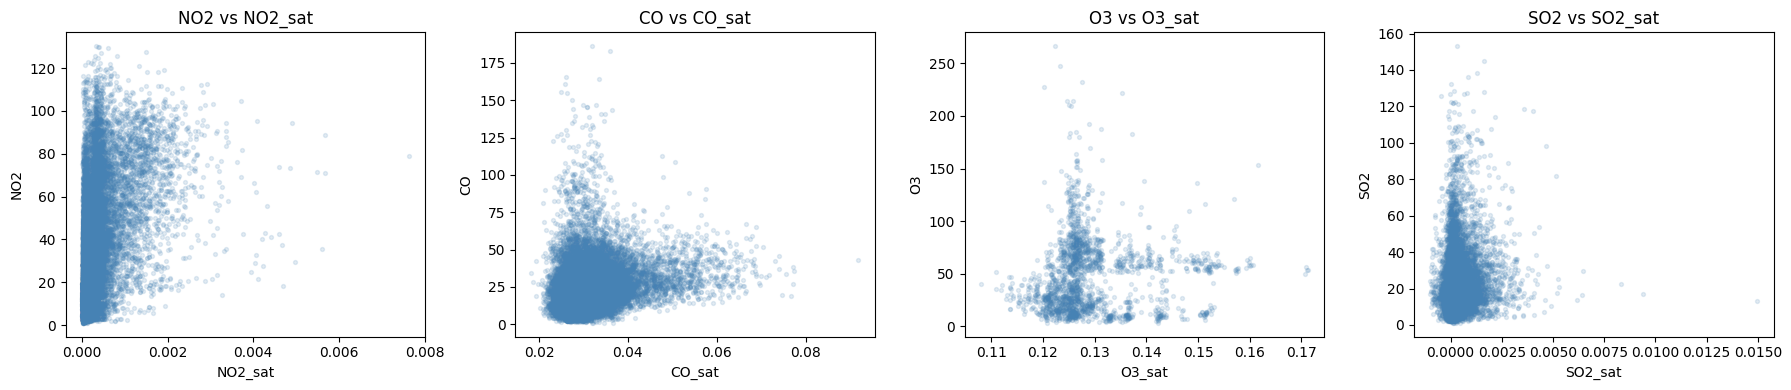

Same-pollutant correlation plots saved.


In [38]:
# Visual scatter check for same-pollutant relationship (NO2_sat vs NO2_ground, etc.)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (ground_col, sat_col) in zip(axes, pairs):
    if ground_col in combined.columns and sat_col in combined.columns:
        valid = combined[[ground_col, sat_col]].dropna()
        if len(valid) > 10:
            ax.scatter(valid[sat_col], valid[ground_col],
                      alpha=0.15, s=8, color='steelblue')
            ax.set_xlabel(sat_col)
            ax.set_ylabel(ground_col.upper())
            ax.set_title(f'{ground_col.upper()} vs {sat_col}')

plt.tight_layout()
plt.savefig('./phase3_satellite_ground_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Same-pollutant correlation plots saved.')

## 5b. Which Satellite Variable Best Predicts Ground PM2.5?
**Why this matters:** Sentinel-5P does not measure PM2.5 directly — only
NO2, CO, O3, SO2 column densities. To build a good PM2.5 prediction model
in Phase 4, we must know which satellite-derived variable (and which
meteorological variable) actually correlates with ground-measured PM2.5.
This ranking directly informs feature selection and model design.

Correlation with ground PM2.5 (ranked by absolute strength):
  CO_sat         : r = +0.294  (weak, positive)
  NO2_sat        : r = +0.234  (weak, positive)
  elevation_m    : r = -0.199  (weak, negative)
  precip_mm      : r = -0.141  (weak, negative)
  SO2_sat        : r = +0.120  (weak, positive)
  humidity_pct   : r = -0.111  (weak, negative)
  O3_sat         : r = -0.102  (weak, negative)
  temp_c         : r = +0.093  (negligible, positive)
  wind_speed     : r = +0.021  (negligible, positive)


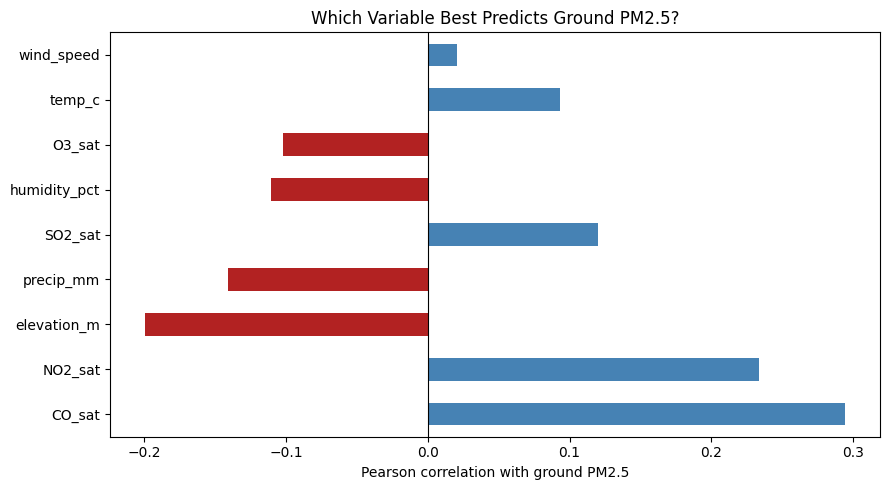


>>> Strongest single predictor: CO_sat (r = +0.294)


In [39]:
if 'pm25' in combined.columns:
    candidate_predictors = [
        'NO2_sat', 'CO_sat', 'O3_sat', 'SO2_sat',
        'temp_c', 'humidity_pct', 'wind_speed',
        'precip_mm', 'elevation_m'
        # NOTE: pressure_hpa intentionally excluded — r=-0.957 with
        # elevation_m (near-perfect collinearity, expected from the
        # barometric formula). elevation_m retained as the more direct,
        # time-invariant spatial feature; pressure_hpa dropped to avoid
        # redundant/unstable feature attribution in RF and LSTM models.
    ]
    candidate_predictors = [c for c in candidate_predictors
                            if c in combined.columns]

    correlations = {}
    for col in candidate_predictors:
        valid = combined[[col, 'pm25']].dropna()
        if len(valid) > 10:
            correlations[col] = valid[col].corr(valid['pm25'])

    corr_series = pd.Series(correlations).sort_values(
        key=abs, ascending=False
    )

    print('Correlation with ground PM2.5 (ranked by absolute strength):')
    print('=' * 55)
    for var, r in corr_series.items():
        direction = 'positive' if r > 0 else 'negative'
        strength  = ('strong' if abs(r) > 0.5 else
                     'moderate' if abs(r) > 0.3 else
                     'weak' if abs(r) > 0.1 else 'negligible')
        print(f'  {var:<15}: r = {r:+.3f}  ({strength}, {direction})')

    # Visualize as a bar chart
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['firebrick' if v < 0 else 'steelblue' for v in corr_series.values]
    corr_series.plot(kind='barh', ax=ax, color=colors)
    ax.set_xlabel('Pearson correlation with ground PM2.5')
    ax.set_title('Which Variable Best Predicts Ground PM2.5?')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.savefig('./phase3_pm25_predictor_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n>>> Strongest single predictor: {corr_series.abs().idxmax()} '
          f'(r = {corr_series[corr_series.abs().idxmax()]:+.3f})')
else:
    print('pm25 column not found in combined dataset.')

## 5c. Spearman Correlation — Capturing Non-Linear Monotonic Relationships
Pearson correlation only detects **linear** relationships. Spearman
correlation (rank-based) detects **monotonic** relationships — i.e. "as X
goes up, does Y consistently go up/down, even if not in a straight line?"

This matters because pollutant dispersion physics is often non-linear
(e.g. saturation effects, threshold effects in atmospheric chemistry).
Comparing Pearson vs Spearman tells us whether a weak linear correlation
hides a stronger non-linear (but still monotonic) relationship — which
Random Forest can exploit even though linear regression cannot.

In [40]:
from scipy.stats import spearmanr

if 'pm25' in combined.columns:
    spearman_results = []
    for col in candidate_predictors:
        valid = combined[['pm25', col]].dropna()
        if len(valid) > 10:
            r_pearson  = valid['pm25'].corr(valid[col])
            r_spearman, p_value = spearmanr(valid['pm25'], valid[col])
            spearman_results.append({
                'variable'      : col,
                'pearson_r'     : round(r_pearson, 3),
                'spearman_r'    : round(r_spearman, 3),
                'spearman_p'    : round(p_value, 4),
                'diff_abs'      : round(abs(r_spearman) - abs(r_pearson), 3),
                'n'             : len(valid)
            })

    spearman_df = pd.DataFrame(spearman_results).sort_values(
        'spearman_r', key=abs, ascending=False
    ).reset_index(drop=True)

    print('Pearson vs Spearman comparison (ranked by |Spearman r|):')
    print('=' * 70)
    print(spearman_df.to_string(index=False))

    print('\nInterpretation guide:')
    print('  diff_abs > 0.05  -> meaningful non-linear monotonic effect present')
    print('  diff_abs ~ 0     -> relationship is essentially linear')
    print('  spearman_p < 0.05 -> statistically significant at 95% confidence')

    notable = spearman_df[spearman_df['diff_abs'] > 0.05]
    if len(notable):
        print(f'\n>>> Variables with notable non-linear signal beyond Pearson:')
        print(notable[['variable','pearson_r','spearman_r']].to_string(index=False))
    else:
        print('\n>>> No variable shows a meaningfully stronger non-linear signal;')
        print('    Pearson and Spearman are largely consistent here.')
else:
    print('pm25 column not found in combined dataset.')

Pearson vs Spearman comparison (ranked by |Spearman r|):
    variable  pearson_r  spearman_r  spearman_p  diff_abs     n
      CO_sat      0.294       0.344         0.0     0.049 29399
     NO2_sat      0.234       0.267         0.0     0.034 29082
 elevation_m     -0.199      -0.230         0.0     0.031 29496
   precip_mm     -0.141      -0.168         0.0     0.027 29329
     SO2_sat      0.120       0.137         0.0     0.017 27144
humidity_pct     -0.111      -0.117         0.0     0.007 29329
      temp_c      0.093       0.086         0.0    -0.007 29329
      O3_sat     -0.102      -0.079         0.0    -0.024 29496
  wind_speed      0.021      -0.029         0.0     0.009 29329

Interpretation guide:
  diff_abs > 0.05  -> meaningful non-linear monotonic effect present
  diff_abs ~ 0     -> relationship is essentially linear
  spearman_p < 0.05 -> statistically significant at 95% confidence

>>> No variable shows a meaningfully stronger non-linear signal;
    Pearson and Spear

*(Note: the full correlation matrix, including lag/rolling features, is built
in Section 6b below — after those features are created in Section 6.)*

## 6. Feature Engineering
Adds temporal context that Random Forest and especially LSTM models rely on:
- Lag features (previous week, 4 weeks ago)
- Rolling means (4-week window) — smooths short-term noise
- Seasonal encoding (cyclical, via sine/cosine of week-of-year)

**Important:** all time-based features are computed *within each station*
and *sorted by week*, so no information leaks across stations or across time.

In [41]:
combined['week_start'] = pd.to_datetime(combined['week_start'])
combined = combined.sort_values(['station_id', 'week_start']).reset_index(drop=True)

# ── Lag & rolling features for satellite pollutants ─────────────────────────
SAT_COLS = ['NO2_sat', 'CO_sat', 'O3_sat', 'SO2_sat']

for col in SAT_COLS:
    if col not in combined.columns:
        continue
    grp = combined.groupby('station_id')[col]
    combined[f'{col}_lag1']      = grp.shift(1)   # previous week
    combined[f'{col}_lag4']      = grp.shift(4)   # 4 weeks ago
    combined[f'{col}_roll4mean'] = (
        grp.transform(lambda x: x.rolling(4, min_periods=2).mean())
    )

# ── Lag & rolling features for ground PM2.5 (target variable) ──────────────
if 'pm25' in combined.columns:
    grp = combined.groupby('station_id')['pm25']
    combined['pm25_lag1']      = grp.shift(1)
    combined['pm25_lag4']      = grp.shift(4)
    combined['pm25_roll4mean'] = (
        grp.transform(lambda x: x.rolling(4, min_periods=2).mean())
    )

# ── Cyclical seasonal encoding (avoids artificial jump from week 52 to 1) ───
combined['week_of_year'] = combined['week_start'].dt.isocalendar().week.astype(int)
combined['week_sin'] = np.sin(2 * np.pi * combined['week_of_year'] / 52)
combined['week_cos'] = np.cos(2 * np.pi * combined['week_of_year'] / 52)

# ── Calendar features ────────────────────────────────────────────────────────
combined['year']  = combined['week_start'].dt.year
combined['month'] = combined['week_start'].dt.month
combined['season'] = combined['month'].map({
    12:'winter', 1:'winter', 2:'winter',
     3:'spring', 4:'spring', 5:'spring',
     6:'summer', 7:'summer', 8:'summer',
     9:'autumn', 10:'autumn', 11:'autumn'
})

print('Feature engineering complete.')
print(f'New shape: {combined.shape}')
print(f'\nNew columns added:')
new_cols = [c for c in combined.columns if any(
    s in c for s in ['_lag', '_roll', 'week_sin', 'week_cos',
                      'week_of_year', 'season']
)]
print(new_cols)

Feature engineering complete.
New shape: (45345, 66)

New columns added:
['NO2_sat_lag1', 'NO2_sat_lag4', 'NO2_sat_roll4mean', 'CO_sat_lag1', 'CO_sat_lag4', 'CO_sat_roll4mean', 'O3_sat_lag1', 'O3_sat_lag4', 'O3_sat_roll4mean', 'SO2_sat_lag1', 'SO2_sat_lag4', 'SO2_sat_roll4mean', 'pm25_lag1', 'pm25_lag4', 'pm25_roll4mean', 'week_of_year', 'week_sin', 'week_cos', 'season']


## 6b. Full Correlation Matrix (Including Engineered Features)
Now that lag/rolling features exist, we build the complete correlation
matrix. This serves two purposes:
1. **Multicollinearity check** — e.g. `NO2_sat` and `NO2_sat_roll4mean` will
   likely be highly correlated; Random Forest tolerates this reasonably well,
   but it is worth knowing for interpretation of feature importances later.
2. **Sanity check on engineered features** — `pm25_lag1` should correlate
   strongly (positively) with `pm25`, confirming the lag was computed
   correctly and temporal ordering was preserved per station.

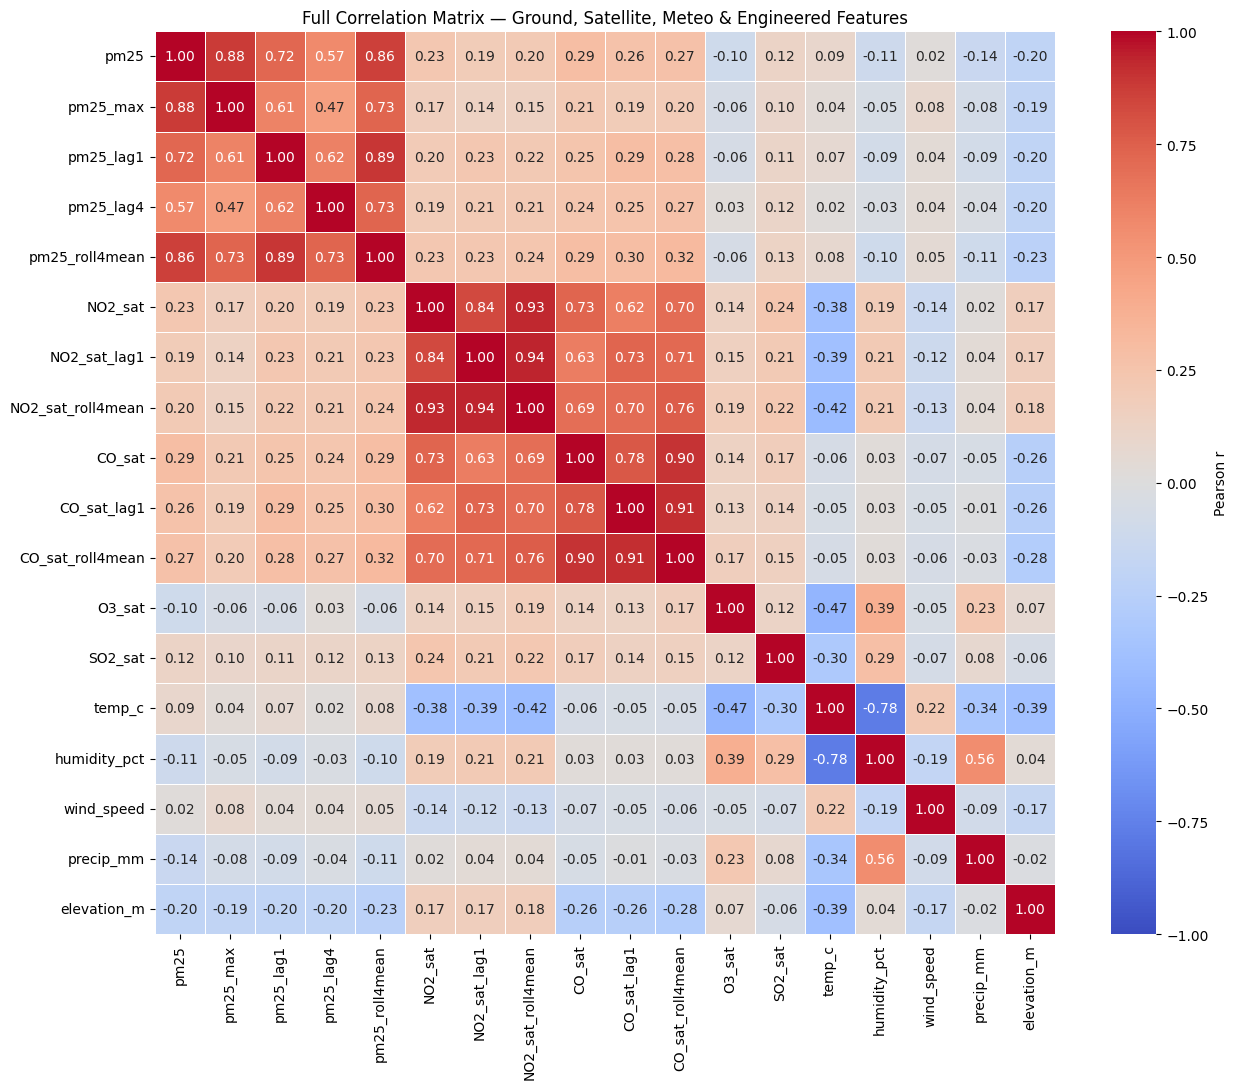

Full correlation matrix saved.

Sanity check — pm25 vs pm25_lag1: r = 0.722 (expected: high positive, confirms correct lag computation)

Predictor pairs with |r| > 0.85 (potential multicollinearity):
  pm25                 <-> pm25_max            : r = 0.877
  pm25                 <-> pm25_roll4mean      : r = 0.864
  pm25_lag1            <-> pm25_roll4mean      : r = 0.891
  NO2_sat              <-> NO2_sat_roll4mean   : r = 0.93
  NO2_sat_lag1         <-> NO2_sat_roll4mean   : r = 0.942
  CO_sat               <-> CO_sat_roll4mean    : r = 0.902
  CO_sat_lag1          <-> CO_sat_roll4mean    : r = 0.914


In [42]:
matrix_cols = [
    'pm25', 'pm25_max', 'pm25_lag1', 'pm25_lag4', 'pm25_roll4mean',
    'NO2_sat', 'NO2_sat_lag1', 'NO2_sat_roll4mean',
    'CO_sat',  'CO_sat_lag1',  'CO_sat_roll4mean',
    'O3_sat',  'SO2_sat',
    'temp_c', 'humidity_pct', 'wind_speed',
    'precip_mm', 'elevation_m'
    # pressure_hpa excluded: r=-0.957 with elevation_m (near-collinear)
]
matrix_cols = [c for c in matrix_cols if c in combined.columns]

corr_matrix = combined[matrix_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Full Correlation Matrix — Ground, Satellite, Meteo & Engineered Features',
             fontsize=12)
plt.tight_layout()
plt.savefig('./phase3_full_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Full correlation matrix saved.')

# Sanity check: lag1 should correlate strongly with the original variable
if 'pm25' in combined.columns and 'pm25_lag1' in combined.columns:
    sanity_corr = combined[['pm25','pm25_lag1']].dropna().corr().iloc[0,1]
    print(f'\nSanity check — pm25 vs pm25_lag1: r = {sanity_corr:.3f} '
          f'(expected: high positive, confirms correct lag computation)')

# Flag any predictor pairs with concerning multicollinearity (|r| > 0.85)
print('\nPredictor pairs with |r| > 0.85 (potential multicollinearity):')
high_corr_pairs = []
for i in range(len(matrix_cols)):
    for j in range(i+1, len(matrix_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append((matrix_cols[i], matrix_cols[j], round(r, 3)))
if high_corr_pairs:
    for v1, v2, r in high_corr_pairs:
        print(f'  {v1:<20} <-> {v2:<20}: r = {r}')
else:
    print('  None found.')

## 7. Final Quality Report

In [43]:
print('=' * 55)
print('FINAL COMBINED DATASET — SUMMARY')
print('=' * 55)
print(f'Shape          : {combined.shape}')
print(f'Stations       : {combined["station_id"].nunique()}')
print(f'Weeks          : {combined["week_start"].nunique()}')
print(f'Date range     : {combined["week_start"].min().date()} -> '
      f'{combined["week_start"].max().date()}')

print('\nMissing data — key columns:')
key_cols = ['pm25','pm10','no2','so2','co','o3',
            'NO2_sat','CO_sat','O3_sat','SO2_sat',
            'temp_c','humidity_pct','elevation_m']
key_cols = [c for c in key_cols if c in combined.columns]
missing_report = (combined[key_cols].isna().mean() * 100).round(1)
print(missing_report.to_string())

print('\nTarget variable (PM2.5) availability:')
print(f'  Rows with valid PM2.5: {combined["pm25"].notna().sum():,} '
      f'({combined["pm25"].notna().mean()*100:.1f}%)')

FINAL COMBINED DATASET — SUMMARY
Shape          : (45345, 66)
Stations       : 200
Weeks          : 351
Date range     : 2018-10-01 -> 2025-07-21

Missing data — key columns:
pm25            35.0
pm10            41.6
no2             63.4
so2             62.8
co              62.6
o3              95.7
NO2_sat          1.3
CO_sat           0.3
O3_sat           0.0
SO2_sat          7.8
temp_c           0.5
humidity_pct     0.5
elevation_m      0.0

Target variable (PM2.5) availability:
  Rows with valid PM2.5: 29,496 (65.0%)


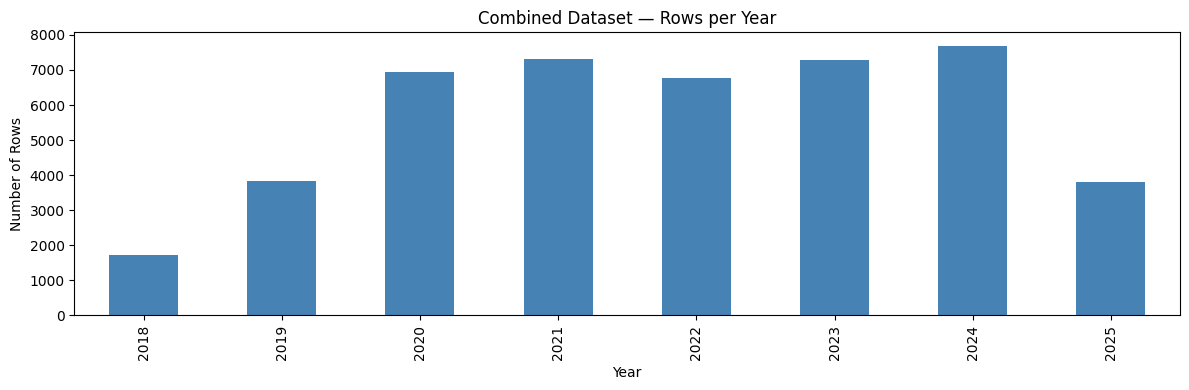

In [44]:
# Temporal coverage plot — rows per year
fig, ax = plt.subplots(figsize=(12, 4))
combined.groupby('year').size().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Combined Dataset — Rows per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Rows')
plt.tight_layout()
plt.savefig('./phase3_yearly_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Final Output

In [45]:
combined['week_start'] = combined['week_start'].dt.strftime('%Y-%m-%d')

# Drop pressure_hpa: near-perfectly collinear with elevation_m (r=-0.957,
# consistent with the barometric formula). elevation_m is the more direct,
# time-invariant spatial feature and is retained as the sole representative
# of this physical relationship to avoid redundant/unstable feature
# attribution in Phase 4 models.
combined = combined.drop(columns=['pressure_hpa'], errors='ignore')

combined.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')

print(f'master_combined.csv saved -> {OUTPUT_FILE}')
print(f'  Shape    : {combined.shape}')
print(f'  Columns  : {len(combined.columns)}')
print(f'\nColumn list:')
for c in combined.columns:
    print(f'  - {c}')

combined.head(10)

master_combined.csv saved -> F:/Amin Ahamadzade/SBU/1405-03-07/Phase-III/Output/1405-04-05/master_combined.csv
  Shape    : (45345, 65)
  Columns  : 65

Column list:
  - station_id
  - week_start
  - NO2_sat
  - CO_sat
  - O3_sat
  - SO2_sat
  - temp_c
  - humidity_pct
  - wind_speed
  - wind_dir
  - precip_mm
  - elevation_m
  - dem_source
  - landuse_class
  - landuse_label
  - lu_tree_cover
  - lu_shrubland
  - lu_grassland
  - lu_cropland
  - lu_built_up
  - lu_bare_desert
  - lu_snow_ice
  - lu_water
  - lu_wetland
  - lu_mangroves
  - lu_moss_lichen
  - pm25
  - pm10
  - no2
  - so2
  - co
  - o3
  - pm25_max
  - pm10_max
  - no2_max
  - so2_max
  - co_max
  - o3_max
  - pm25_n_obs
  - pm10_n_obs
  - no2_n_obs
  - so2_n_obs
  - co_n_obs
  - o3_n_obs
  - NO2_sat_lag1
  - NO2_sat_lag4
  - NO2_sat_roll4mean
  - CO_sat_lag1
  - CO_sat_lag4
  - CO_sat_roll4mean
  - O3_sat_lag1
  - O3_sat_lag4
  - O3_sat_roll4mean
  - SO2_sat_lag1
  - SO2_sat_lag4
  - SO2_sat_roll4mean
  - pm25_lag1
  

,station_id,week_start,NO2_sat,CO_sat,O3_sat,SO2_sat,temp_c,humidity_pct,wind_speed,wind_dir,...,SO2_sat_roll4mean,pm25_lag1,pm25_lag4,pm25_roll4mean,week_of_year,week_sin,week_cos,year,month,season
0,"abadan,-abadan, khouzestan, iran-air-quality",2018-10-01,0.000112,0.031880,0.123371,NaN,33.930568,19.412369,2.330960,305.932405,...,NaN,NaN,NaN,NaN,40,-0.992709,0.120537,2018,10,autumn
1,"abadan,-abadan, khouzestan, iran-air-quality",2018-10-08,0.000087,0.029427,0.123660,NaN,32.497718,34.961458,0.789910,152.103995,...,NaN,NaN,NaN,NaN,41,-0.970942,0.239316,2018,10,autumn
2,"abadan,-abadan, khouzestan, iran-air-quality",2018-10-15,0.000095,0.028232,0.125527,NaN,29.971695,37.807336,0.105377,195.299275,...,NaN,NaN,NaN,NaN,42,-0.935016,0.354605,2018,10,autumn
3,"abadan,-abadan, khouzestan, iran-air-quality",2018-10-22,0.000077,0.026111,0.118861,NaN,25.730571,59.276891,0.109446,102.930664,...,NaN,NaN,NaN,NaN,43,-0.885456,0.464723,2018,10,autumn
4,"abadan,-abadan, khouzestan, iran-air-quality",2018-10-29,0.000121,0.029188,0.129403,NaN,21.687174,50.534928,1.696667,319.718554,...,NaN,NaN,NaN,NaN,44,-0.822984,0.568065,2018,10,autumn
5,"abadan,-abadan, khouzestan, iran-air-quality",2018-11-05,0.000063,0.027480,0.119164,NaN,20.951268,86.967860,0.830582,122.199868,...,NaN,NaN,NaN,NaN,45,-0.748511,0.663123,2018,11,autumn
6,"abadan,-abadan, khouzestan, iran-air-quality",2018-11-12,0.000044,0.028097,0.119499,NaN,19.117608,83.730643,1.003468,334.690133,...,NaN,NaN,NaN,NaN,46,-0.663123,0.748511,2018,11,autumn
7,"abadan,-abadan, khouzestan, iran-air-quality",2018-11-19,0.000068,0.030681,0.122379,NaN,17.062693,83.972395,1.171061,214.370005,...,NaN,NaN,NaN,NaN,47,-0.568065,0.822984,2018,11,autumn
8,"abadan,-abadan, khouzestan, iran-air-quality",2018-11-26,0.000080,0.028824,0.117501,0.001112,16.785005,85.407137,1.247160,311.275230,...,NaN,NaN,NaN,NaN,48,-0.464723,0.885456,2018,11,autumn
9,"abadan,-abadan, khouzestan, iran-air-quality",2018-12-03,0.000095,0.031666,0.113577,0.000228,17.184879,81.940146,0.581883,145.050362,...,0.00067,NaN,NaN,NaN,49,-0.354605,0.935016,2018,12,winter


---
## Phase 3 Complete

**Output files:**
- `master_combined.csv` — final weekly, station-level dataset, ready for Phase 4
- `phase3_satellite_ground_correlation.png` — sanity-check scatter plots
- `phase3_yearly_coverage.png` — temporal coverage visualization

**Methodology summary (for thesis):**
1. Daily ground measurements aggregated to Monday-aligned weekly statistics
2. Both weekly **mean** (overall pollution level) and weekly **max** (peak
   exposure) are retained as separate candidate features; their relative
   predictive value will be compared empirically in Phase 4
3. Weekly statistics require >= 3 valid daily observations; otherwise
   discarded (set to NaN) to avoid unreliable estimates from sparse data
4. Ground (weekly) and satellite data joined via inner join on
   (station_id, week_start)
5. Cross-correlation analysis ranks satellite/meteorological variables by
   their association with ground PM2.5 — guides feature prioritization
6. Lag (1-week, 4-week) and rolling (4-week mean) features added per
   station, respecting time order (no cross-station or future leakage)
7. Cyclical seasonal encoding (sine/cosine of week-of-year) avoids artificial
   discontinuity between week 52 and week 1

**Next: Phase 4** — Train Random Forest and LSTM models to predict PM2.5
from satellite + meteorological + static features.